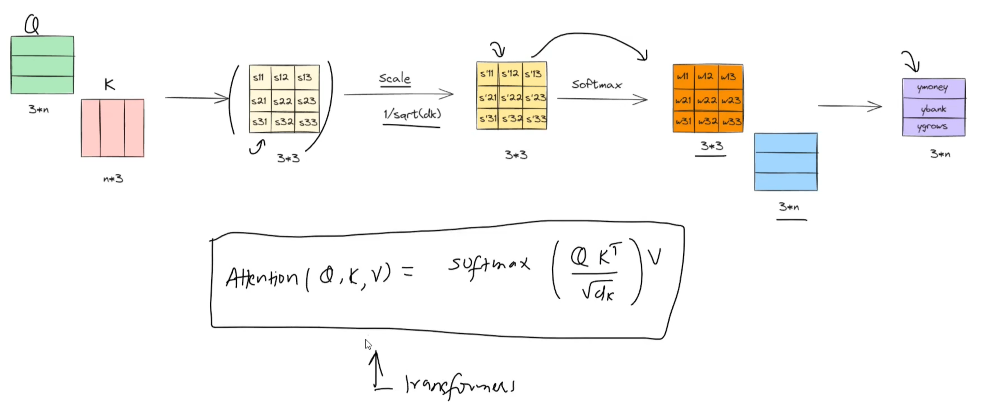

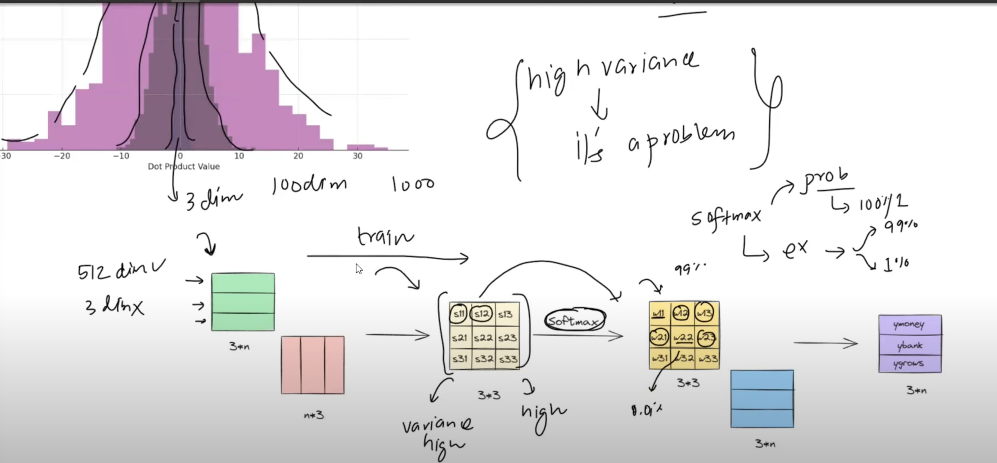

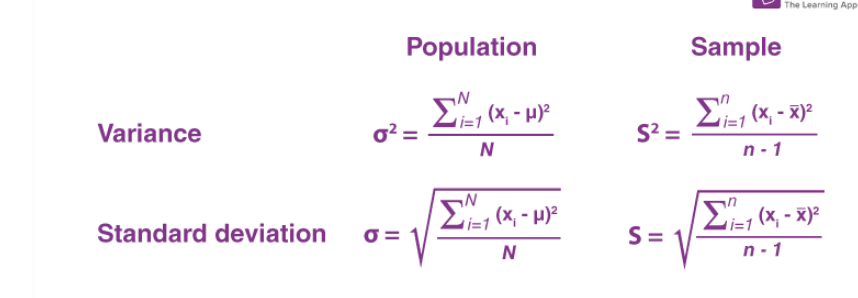

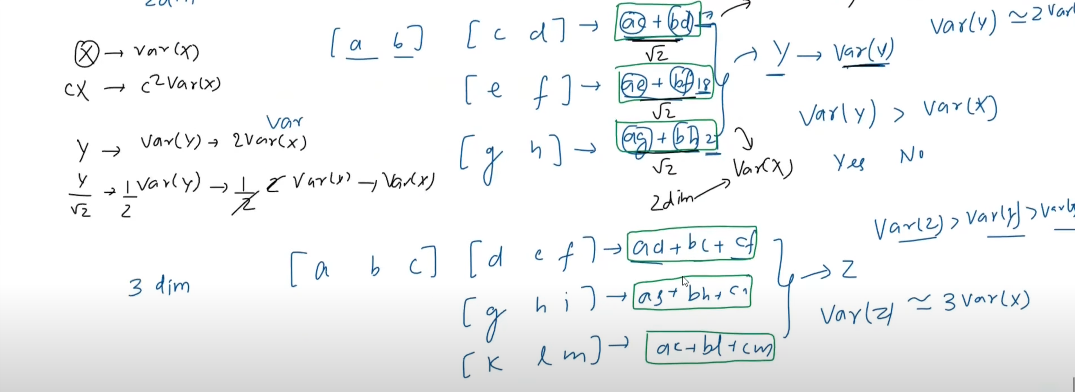

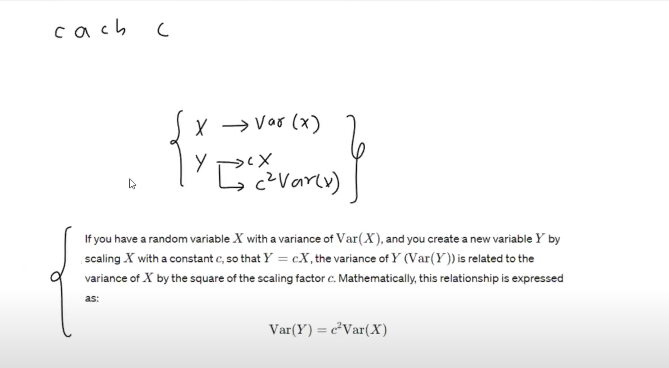



 **why the dot product attention in the Transformer model is scaled by the square root of the key vector's dimension (√dk)**. This scaling factor, `1/√dk`, is critical for ensuring **stable training** of the model by preventing **vanishing gradients** when dealing with high-dimensional embeddings.

### Steps and Intuition Behind the Work



1.  **Recap of Self-Attention Calculation:**
    *   The process begins by taking a sequence of words (e.g., "Money Bank Grows").
    *   Each word is converted into an **embedding** (e.g., E_money, E_bank, E_grows), which is a numerical representation.
    *   These embeddings are then projected into three different spaces using learned parameter matrices: **W_Q** (Query), **W_K** (Key), and **W_V** (Value). This generates **Query (Q), Key (K), and Value (V) vectors** for each word.
    *   These individual vectors are stacked to form **Query (Q), Key (K), and Value (V) matrices**.
    *   The standard self-attention computation then involves:
        *   Calculating the **dot product** of the **Query matrix (Q)** and the **transpose of the Key matrix (K^T)**: `Q * K^T`. This results in a matrix where each element represents the compatibility (or relevance) between a query and a key.
        *   Applying a **softmax function** to this result to obtain attention weights (probabilities).
        *   Multiplying these attention weights by the **Value matrix (V)**: `softmax(Q * K^T) * V`. This final result provides **contextual embeddings** for each word.

2.  **Introducing the Discrepancy – The Scaling Factor:**
    *   The video points out that the self-attention formula derived from first principles (`softmax(Q * K^T) * V`) differs from the one presented in the original Transformer paper, "Attention Is All You Need".
    *   The Transformer paper's formula includes a **scaling factor**: `Attention(Q, K, V) = softmax(Q * K^T / √dk) * V`.
    *   **`dk`** represents the **dimension of the Key vectors**. For example, if the key vectors are 512-dimensional, `dk = 512`. The scaling means that every value in the `Q * K^T` matrix is divided by `√dk`.

3.  **The "Why" – The Nature of the Dot Product and High Variance Problem:**
    *   The fundamental reason for scaling lies in the **"nature of the dot product"**.
    *   The `Q * K^T` operation essentially performs multiple dot products between individual query and key vectors.
    *   **Observation:** When vectors have **low dimensions**, the dot products tend to have **low variance**. However, when vectors have **high dimensions**, their dot products result in a **high variance**. This is demonstrated through simulations where increasing vector dimensions (e.g., from 3D to 100D to 1000D) leads to a much wider spread (higher variance) in the distribution of dot product values.
    *   **Problem with High Variance and Softmax:**
        *   The **softmax function** contains an exponential, meaning it is highly sensitive to the magnitude of its inputs.
        *   If the numbers in the `Q * K^T` matrix have high variance (due to large `dk`), some values will be significantly larger than others.
        *   Softmax will then **"sharpen"** the probability distribution, assigning **extremely high probabilities** to the large values and **extremely low (near zero) probabilities** to the small values.
        *   **Impact on Training:** During **backpropagation**, the training process (updating model weights based on gradients) will disproportionately focus on the parameters associated with these very large attention scores. The parameters corresponding to the small (near-zero) attention scores will receive **vanishingly small gradients**, effectively **ignoring them**. This leads to **unstable training** where only a subset of relationships (those with high attention scores) are learned, and the model struggles to generalize.
    *   **Analogy:** The video uses an analogy of a classroom where students have varying heights (representing variance). A teacher responding only to the tallest students (high attention scores) neglects the shorter students (low attention scores), leading to incomplete learning for the whole class.

4.  **The Solution – Scaling to Control Variance:**
    *   While using low-dimensional embeddings would reduce variance, it would also mean losing crucial information necessary for complex tasks.
    *   The goal is to **reduce the variance of the `Q * K^T` values** while retaining high-dimensional embeddings.
    *   The video shows that **dividing numbers by a constant reduces their variance**.
    *   **Quantifying Variance Growth:** Mathematically, the video demonstrates that the variance of the dot product of two vectors grows **linearly** with their dimension `D`. If `Var(X)` is the variance for 1-dimensional vectors, then for `D`-dimensional vectors, the variance becomes approximately `D * Var(X)`.
    *   **Applying a Mathematical Rule:** A known statistical property states that if a random variable `X` has variance `Var(X)`, then scaling `X` by a constant `C` (i.e., `C*X`) results in a new variance of `C^2 * Var(X)`.
    *   To counteract the linear growth `D * Var(X)` and keep the variance constant at `Var(X)`, one must scale by `1/√D`. Specifically, if we have a variance of `D * Var(X)` and we multiply by `1/√D`, the new variance will be `(1/√D)^2 * (D * Var(X)) = (1/D) * D * Var(X) = Var(X)`.
    *   Therefore, **dividing the `Q * K^T` values by `√dk`** effectively normalizes their variance, preventing the softmax from producing overly extreme probabilities. This ensures that all relationships, regardless of their initial magnitude, receive appropriate attention during training, leading to **more stable and effective learning**.

In summary, the scaling factor `1/√dk` in Scaled Dot-Product Attention is a mathematical necessity to maintain stable training by controlling the variance of the attention scores before they are passed through the softmax function. This ensures that gradients remain well-behaved, allowing the model to learn from a diverse range of dependencies across the sequence.



*   **What is the Transformer architecture?**
    The Transformer is a **new network architecture that relies entirely on attention mechanisms**, completely removing the need for recurrence and convolutions. Its main goal is to reduce sequential computation in models.

*   **What is Self-Attention?**
    Self-attention, also known as intra-attention, is an attention mechanism that **connects different parts of a single sequence** to create a representation of that sequence.

*   **What is Scaled Dot-Product Attention, and what is its formula?**
    It's a specific attention function where queries (Q) and keys (K) have dimension `dk`, and values (V) have dimension `dv`. The formula, proposed by Noam Shazeer, is: **`Attention(Q, K, V) = softmax(QKT / √dk)V`**.

*   **What does `dk` represent in the scaling factor `√dk`?**
    `dk` is the **dimension of the Key vectors**. For example, if key vectors are 512-dimensional, then `dk = 512`.

*   **Why is the scaling factor `1/√dk` necessary in Scaled Dot-Product Attention?**
    The scaling factor `1/√dk` is crucial for **stable training** and preventing problems like vanishing gradients.
    *   **Problem:** When `dk` is large (high-dimensional vectors), the dot products of queries and keys (`QKT`) tend to **grow large in magnitude and have high variance**. The softmax function, which includes an exponential, is highly sensitive to large inputs, causing it to produce **extremely high probabilities for large values and near-zero probabilities for small values**.
    *   **Impact on Training:** This extreme distribution means that during backpropagation, the model's training process will **disproportionately focus on parameters related to large attention scores**, while parameters for small scores receive **very small (vanishing) gradients** and are effectively ignored. This leads to unstable or incomplete learning.
    *   **Solution & Intuition:** To maintain stable training, the **variance of the dot products needs to be controlled**. Mathematically, the variance of dot products grows linearly with their dimension `D` (roughly `D * Var(X)`). By dividing the dot products by `√dk`, the variance is normalized and kept constant, regardless of `dk`'s magnitude. This prevents extreme softmax outputs and ensures all relationships are properly considered during learning.

*   **What is Multi-Head Attention?**
    Instead of one attention function, Multi-Head Attention **performs several attention functions in parallel**, each with different learned linear projections of queries, keys, and values. The outputs from these parallel "heads" are then concatenated and projected again. This allows the model to **attend to information from different representation subspaces and different positions jointly**.

*   **How does the Transformer handle the order of a sequence without recurrence?**
    The Transformer uses **"positional encodings"**. These are added to the input embeddings and use **sine and cosine functions of different frequencies** to provide the model with information about the relative or absolute position of tokens in the sequence.

*   **What are the key advantages of the Transformer compared to previous models?**
    *   **Greater parallelization**: It overcomes the inherently sequential nature of recurrent models, allowing for significantly more parallel computation.
    *   **Faster training**: It requires significantly less time to train, achieving state-of-the-art results in translation tasks with a fraction of the training cost of previous models.
    *   **Improved quality**: It achieves superior quality in tasks like machine translation, setting new state-of-the-art BLEU scores.
    *   **Better handling of long-range dependencies**: Self-attention layers connect all positions with a constant number of sequential operations, making it easier to learn long-range dependencies compared to recurrent (O(n) sequential operations) or convolutional (O(logk(n)) path length) layers.

#Self Attention Geometric Intuition | How to Visualize Self Attention

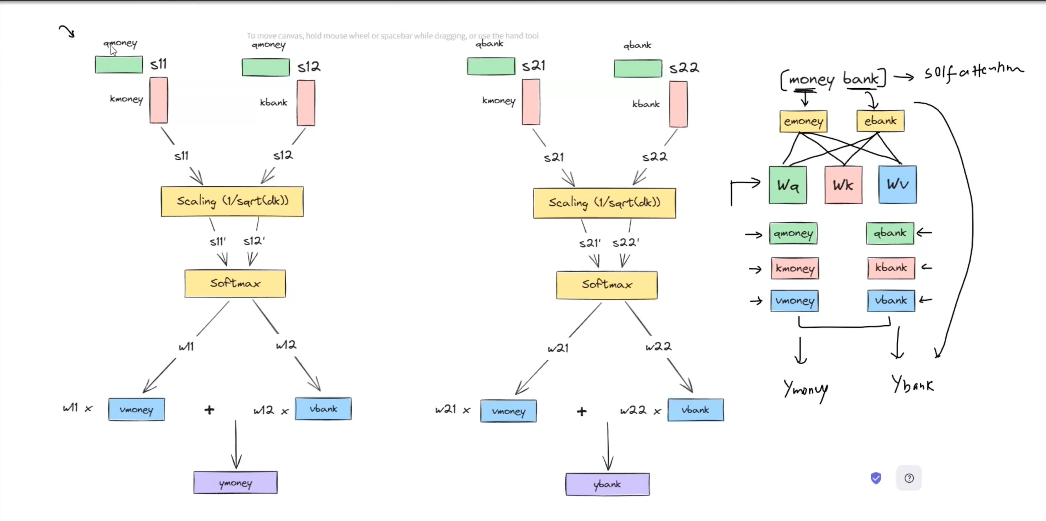

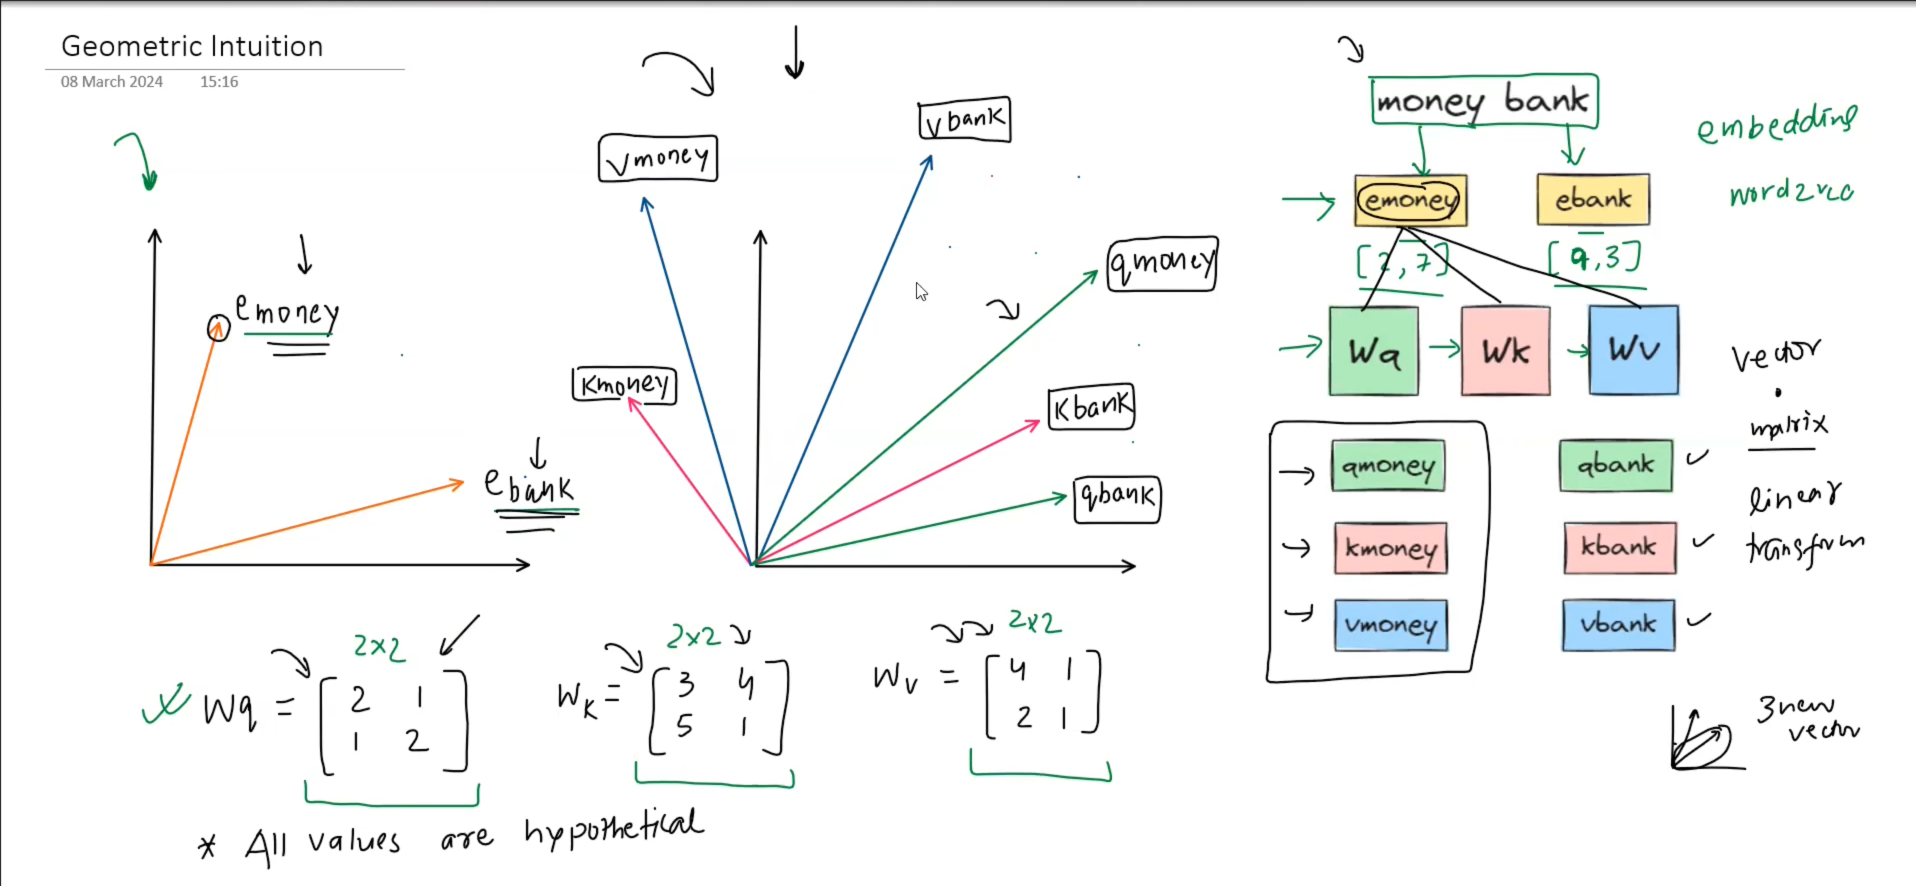

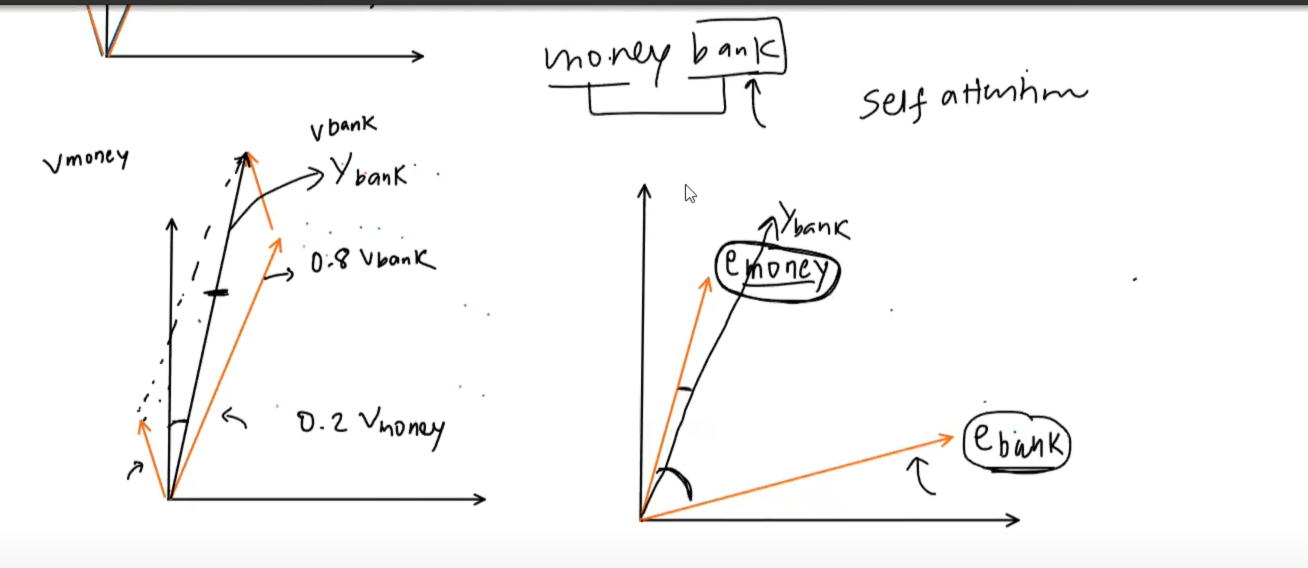

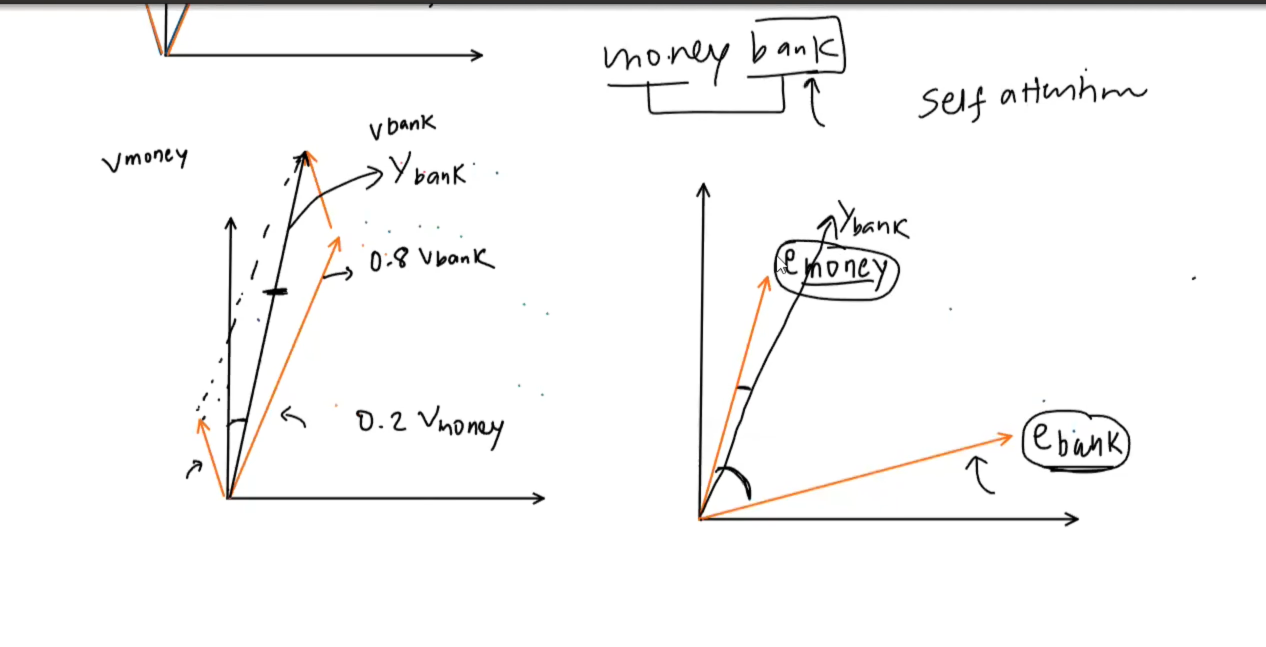

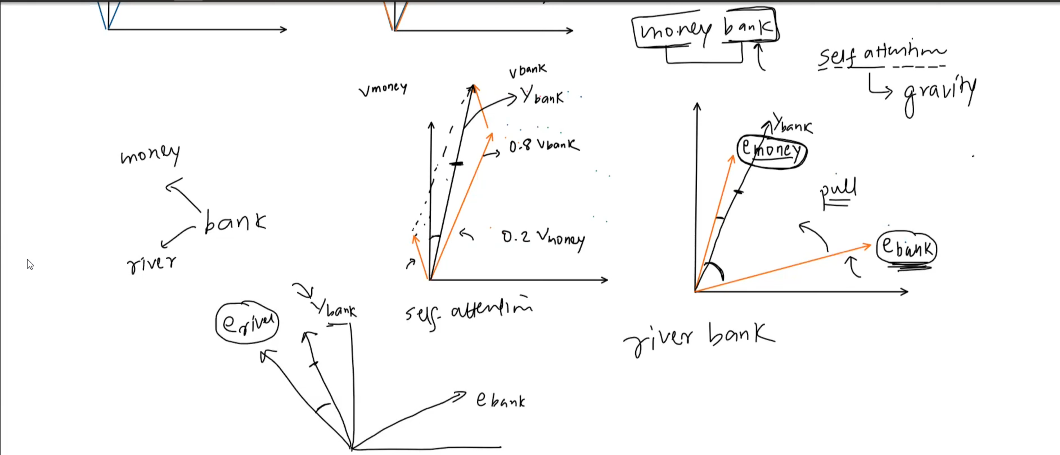

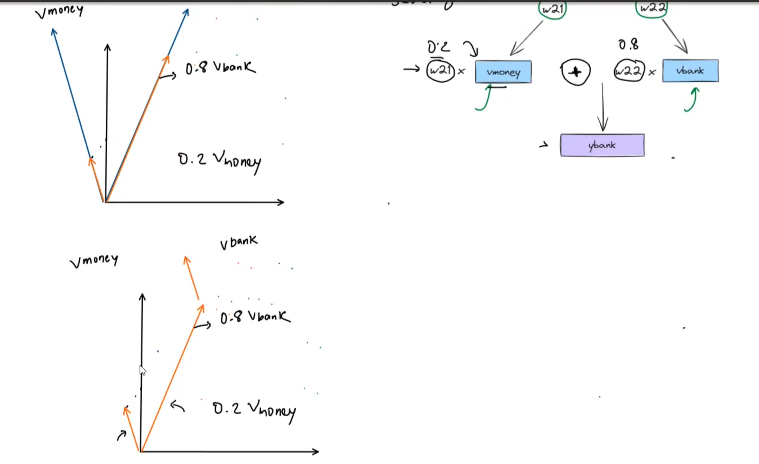





*   **Core Purpose: Contextualized Word Representations**
    Self-attention, also known as intra-attention, relates different positions of a single sequence to compute a representation of that sequence [Previous Q&A]. Its primary goal is to **generate word embeddings that are aware of their context** within a sentence. This means that the representation of a word like "bank" will change depending on whether it's used with "money" or "river".

*   **Mathematical Formulation (Quick Recap)**
    1.  **Embeddings**: Each word in a sentence (e.g., "money," "bank") is first converted into an **embedding vector**. These embeddings can be visualized as points or vectors in a multi-dimensional space where semantically similar words are positioned closer together.
    2.  **Query, Key, Value (Q, K, V) Vectors**: For each word embedding, three new vectors—Query (Q), Key (K), and Value (V)—are generated. This is achieved by **linearly transforming** the original embedding vector using three different learned matrices: WQ, WK, and WV. Geometrically, multiplying an embedding vector by these matrices moves the vector to a new location in the vector space, creating three distinct transformed vectors from a single input.
    3.  **Similarity Scores**: To understand how much a word (Query) relates to other words (Keys), a **dot product** is computed between the Query vector of the current word and the Key vectors of all words in the sequence. Geometrically, the dot product provides a measure of **similarity based on the angular distance** between these vectors; a smaller angle indicates higher similarity and a larger dot product.
    4.  **Scaling**: These raw similarity scores are then **divided by the square root of `dk`** (`√dk`), where `dk` is the dimension of the Key vectors. This scaling factor is crucial because it prevents large dot products (which tend to occur with high-dimensional `dk`) from pushing the softmax function into regions with extremely small gradients, thereby ensuring **stable training** [Previous Q&A].
    5.  **Softmax Normalization**: The scaled scores are normalized using a **softmax function** to obtain attention weights. These weights sum to one and represent the importance of each word's Value vector for the current word's new representation.
    6.  **Weighted Sum of Values**: Finally, these attention weights are used to compute a **weighted sum of the Value (V) vectors** from all words in the sequence. This weighted sum produces the new, contextualized embedding vector for the original word.

*   **Geometric Intuition: The "Gravity" Effect**
    The final contextualized embedding for a word (e.g., Y_bank) is created through **vector scaling and addition** of the Value vectors. This process has a profound geometric effect:
    *   If you start with an original embedding vector for "bank" and apply self-attention in the context of "money," the resulting **contextualized "Y_bank" vector will move in the vector space, pulling closer to the "V_money" vector (representing "money")**.
    *   This movement is dynamic and **context-dependent**. If "bank" were used in the context of "river," its contextualized embedding would be pulled towards the "river" vector instead.
    *   This phenomenon is likened to **"gravity,"** where words that are semantically related or frequently co-occur pull each other closer in the embedding space. Self-attention, therefore, acts as a mechanism to **re-position word embeddings based on the specific words they interact with** in a sentence, enhancing their meaning and representation.

In essence, Self-Attention allows the Transformer to understand how words relate to each other within a sentence, creating rich, context-aware representations by geometrically adjusting their positions in a vector space.


Here's the breakdown of this geometric "gravity" effect:

*   **Initial Embeddings as Points/Vectors:** Words like "money" and "bank" are initially represented as distinct **embedding vectors**, visualized as points or lines in a multi-dimensional space, where semantic similarity influences proximity.
*   **Q, K, V Transformations as Vector Movements:** From each initial word embedding, three new vectors (Query, Key, Value) are generated by multiplying the original embedding with different learned matrices (WQ, WK, WV). Geometrically, these matrix multiplications perform **linear transformations, effectively moving the original vector to new locations** in the vector space to create the Q, K, and V vectors.
*   **Weighted Sum of Value Vectors for New Position:** The "similarity scores" (dot products of Query and Keys, scaled and then normalized by softmax to get attention weights) are used to compute a **weighted sum of all Value (V) vectors**. Geometrically, this involves **scaling individual Value vectors** by their respective attention weights and then **adding these scaled vectors together** (e.g., using the parallelogram law of vector addition).
*   **The "Gravity" Effect – Contextual Repositioning:** The most crucial geometric insight is that this final **vector addition process pulls the contextualized embedding (e.g., Y_bank) closer to the Value vectors of other words it is semantically related to** within that specific sentence. For example, in "money bank," the "Y_bank" vector moves closer to "V_money." This dynamic pulling is likened to **"gravity,"** where a word (like "money") exerts an influence, pulling other related words (like "bank") towards itself in the embedding space.
*   **Context-Aware Dynamic Movement:** This repositioning is **context-dependent**. If "bank" were used in "river bank," its contextualized embedding would be pulled towards the "river" vector instead of "money," demonstrating Self-Attention's power to represent words based on their specific usage and surrounding words.



#Why is Self Attention called "Self"? | Self Attention Vs Luong Attention

The essence of the provided source is to **explain why Self-Attention, a fundamental component of Transformer architecture, is named "Self-Attention"** by dissecting the meaning of both "Attention" and "Self". The video emphasizes that a deep understanding of Self-Attention is crucial for grasping the Transformer architecture.

Here are the key points from the source:

*   **Why Self-Attention is an "Attention" Mechanism:**
    *   The video argues that Self-Attention is indeed an attention mechanism because its **mathematical formulation and core operations are conceptually identical** to traditional attention mechanisms like Luong Attention.
    *   In traditional attention, a decoder's hidden state (Query) is compared to encoder hidden states (Keys) using a dot product to calculate alignment scores. These scores are then soft-maxed to get weights, which are used to take a weighted sum of encoder hidden states (Values) to form a context vector.
    *   Self-Attention follows the exact same three operations:
        1.  **Query-Key Dot Product:** It calculates similarity scores by taking the dot product of a word's **Query vector (analogous to the decoder's hidden state)** with the **Key vectors (analogous to encoder hidden states)** of all words in the sentence.
        2.  **Softmax for Weights:** These similarity scores are then processed through a softmax function to produce attention weights.
        3.  **Weighted Sum of Values:** Finally, these weights are used to compute a **weighted sum of the Value vectors (analogous to encoder hidden states)** of all words, resulting in a contextualized embedding for the original word.
    *   Because it reuses these same fundamental operations in a different setting, it is inherently an attention mechanism.

*   **Why it is called "Self":**
    *   The "Self" aspect distinguishes it from other attention types, like Luong Attention, which operate **between two distinct sequences** (e.g., an English input sentence and a Hindi output sentence). This is referred to as "inter-sequence attention".
    *   In contrast, Self-Attention calculates attention **within the same sequence**. It takes a single sentence (e.g., "Turn off the lights") and computes the alignment or similarity scores of each word with every other word *in that same sentence*.
    *   Therefore, because the attention mechanism is applied to the sequence "itself" to generate contextualized representations, it is called "Self-Attention".





---

# 🔹 1. Luong Attention (a type of seq2seq attention)

This is used in encoder–decoder models for machine translation.

### Inputs:

* Encoder hidden states: $h_1, h_2, \dots, h_T$, each $h_i \in \mathbb{R}^d$
* Decoder hidden state at time step $t$: $s_t \in \mathbb{R}^d$

---

### Steps:

**Step 1. Score function (Luong used “dot” or “general”)**

$$
\text{score}(s_t, h_i) =
\begin{cases}
s_t^\top h_i & \text{(dot)} \\
s_t^\top W_a h_i & \text{(general)} \\
\end{cases}
$$

where $W_a$ is a learnable matrix.

---

**Step 2. Alignment (softmax over encoder positions)**

$$
\alpha_{t,i} = \frac{\exp(\text{score}(s_t, h_i))}{\sum_{j=1}^T \exp(\text{score}(s_t, h_j))}
$$

---

**Step 3. Context vector**

$$
c_t = \sum_{i=1}^T \alpha_{t,i} h_i
$$

---

**Step 4. Combine with decoder state**

Luong suggested concatenating context and decoder state:

$$
\tilde{s}_t = \tanh(W_c [c_t ; s_t])
$$

This $\tilde{s}_t$ is used to predict the next token.

---

✅ **Intuition:** Decoder state $s_t$ queries the encoder hidden states to form a context vector.

---

# 🔹 2. Self-Attention (Transformer)

Instead of encoder–decoder separation, **every token attends to every other token** in the sequence.

### Inputs:

* Sequence of embeddings: $x_1, x_2, \dots, x_T$, each $x_i \in \mathbb{R}^d$

---

### Steps:

**Step 1. Linear projections into Query, Key, Value**

$$
Q = X W_Q, \quad K = X W_K, \quad V = X W_V
$$

where

* $Q, K, V \in \mathbb{R}^{T \times d_k}$
* $W_Q, W_K, W_V \in \mathbb{R}^{d \times d_k}$

---

**Step 2. Attention scores (scaled dot product)**

$$
\text{scores} = \frac{QK^\top}{\sqrt{d_k}}
$$

This gives a $T \times T$ matrix: each token compares itself to every other token.

---

**Step 3. Softmax normalization**

$$
\alpha = \text{softmax}(\text{scores})
$$

where each row sums to 1 (distribution over tokens).

---

**Step 4. Weighted sum of values**

$$
Z = \alpha V
$$

where $Z \in \mathbb{R}^{T \times d_k}$ is the new representation.

---

✅ **Intuition:** Each token looks at all tokens (including itself) to build its new representation.

---

# 🔹 3. Key Differences (Math + Intuition)

| Aspect             | Luong Attention                     | Self-Attention                       |
| ------------------ | ----------------------------------- | ------------------------------------ |
| **Query source**   | Decoder state $s_t$                 | Each token embedding $x_i$           |
| **Keys/Values**    | Encoder hidden states $h_i$         | Same sequence embeddings (projected) |
| **Score function** | $s_t^\top h_i$ (dot/general)        | $q_i^\top k_j / \sqrt{d_k}$          |
| **Context vector** | One per decoder step                | One per token (parallel for all)     |
| **Direction**      | Decoder → Encoder (cross attention) | Within-sequence (self-attention)     |

---

👉 In short:

* **Luong Attention**: Decoder hidden state queries encoder states.
* **Self-Attention**: Every token queries every other token in the same sequence.

---




— why it’s called **self-attention**, and why we even call it **attention** if there’s no encoder–decoder structure like in Luong’s case.

---

# 🔹 Why is it called **Self-Attention**?

The name comes from **who is attending to whom**:

* In **Luong (cross) attention**:

  * Queries come from the **decoder state** ($s_t$)
  * Keys/Values come from the **encoder states** ($h_i$)
  * So the decoder attends to the encoder.

* In **Self-Attention**:

  * Queries, Keys, and Values all come from the **same sequence** (the input $X$).
  * Every token’s embedding attends to (interacts with) other tokens’ embeddings **within the same sequence**.

So the “self” means **a sequence attends to itself** rather than another sequence.

---

# 🔹 Why still called **Attention**?

Even though there’s no encoder–decoder separation, the **mathematical mechanism** is the same as attention:

1. Compute a **score** between a query and a set of keys.

   * Luong: $\text{score}(s_t, h_i)$
   * Self-Attention: $\text{score}(q_i, k_j) = \frac{q_i^\top k_j}{\sqrt{d_k}}$

2. Turn scores into a **probability distribution** with softmax.

3. Use these weights to compute a **weighted sum of values**.

That’s exactly the **attention mechanism**, just applied within the same sequence instead of across encoder and decoder.

---

# 🔹 Why no Encoder–Decoder?

Great observation! In Transformers, attention is generalized:

* **Encoder-only models** (e.g., BERT):
  Use self-attention inside the encoder. No decoder needed.
  (Useful for classification, embeddings, etc.)

* **Decoder-only models** (e.g., GPT):
  Use self-attention inside the decoder, with causal masking (each token can only attend to previous tokens).
  No separate encoder needed.

* **Encoder–Decoder models** (e.g., original Transformer for translation):
  Use self-attention inside encoder, self-attention inside decoder, **and** cross-attention from decoder → encoder (similar to Luong).

So **self-attention is more general** — it works whether you have encoder+decoder, only encoder, or only decoder.

---

✅ **In short:**

* It’s called **self-attention** because queries, keys, and values all come from the same sequence.
* It’s called **attention** because it follows the same weighting mechanism as Luong’s attention.
* Unlike Luong’s case, you don’t *need* an encoder–decoder structure — self-attention works inside any sequence.

---


